### Solving Time Series Problems Using Simple RNN

In [2]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached grpcio-1.80.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ashwi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [5]:
%pip install keras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ashwi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

In [8]:
##from google.colab import drive
### drive.mount('/drive')

In [9]:
df = pd.read_csv('airline-passengers.csv')
df.sort_index(inplace=True)
df.tail(4)

,Month,Passengers
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


In [10]:
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [11]:
df.shape

(144, 2)

<Axes: >

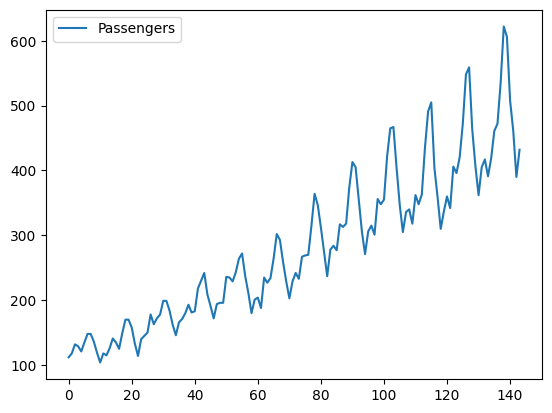

In [12]:
df.plot()

### Data Preprocessing

In [13]:
#Check for null values
df.isnull().sum()

Month         0
Passengers    0
dtype: int64

###### Drop the month column
 - month column serves just a representational need

In [23]:
df.drop("Month", axis=1, inplace=True)

- lstms are sensitive to sclaing. Specifically when we use activation functions like sigmoid or tanh
- a good practice is to rescale the data to the range of o to 1
- this is also called normalization or standardization.
- MinMaxScaler library helps in scaling 

In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
#Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df)

##### check the scaled data

In [26]:
type(scaled)

numpy.ndarray

In [27]:
scaled.ndim

2

In [28]:
scaled.shape

(144, 1)

In [29]:
scaled

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

### Split Data - Points to be considered for time series problems
- Splitting the dataset into training or text

- Usual methodology to split data into train and test is by using 
     - sklearn.model_selection import train_test_split
     - X_train, X_test, y_train, y_test = train_test_split(X, y)
     
- With timeseries the above approach will not work. Because, above methodology of splitting can make 
  - an observation at time step t can be in training data set
  - another observation at time step t+1 can go to test data set
  
 - Observations in our time series datasets are not independent.

  - As a simple example, if your observations are autocorrelated, having an observation at time t in the training set and another observation at time t+1 in the test set would cause a trouble. 

- A model which knows the former naturally predict the latter well. In that case, the test score will be too optimistic about the predictive power of the model.
  
   


In [30]:
#70% examples will used for training (in the begining)
train_size = int(len(scaled) * 0.70)

#30% will be used for Test
test_size = len(scaled) - train_size

In [31]:
train_size

100

In [32]:
test_size

44

In [33]:
#Split the data - remember this is not a typical train test split using sci-kit learn
train, test = scaled[0:train_size, :], scaled[train_size: len(scaled), :]
print('train: {}\ntest: {}'.format(len(train), len(test)))

train: 100
test: 44


### Build Input and Output data
for both Training and Test

######  Build_Ts_Data - Create a new function
- The function takes two arguments:
 - Ts_Dataset, is a NumPy array that we want to convert into a dataset, 
 - Ts_Window -  is the number of previous time steps to use as input variables to predict the next 
    time period — in this example, we have defaulted to 1.

 - This default will create a dataset where 
      - dataX is the number of passengers at a given time (t) and 
      - dataY is the number of passengers at the next time (t + 1).
      orig  predict
      100   122
      122   133
      133  


In [34]:
#window - how long the sequence will be
def create_dataset(dataset, window=1):
    
        ### initialize the list that houses the number of passengers at time t
    dataX, dataY = [], []
    
    for i in range(len(dataset)-window):
        
        a = dataset[i:(i+window), 0]        
        dataX.append(a)
        dataY.append(dataset[i + window, 0])
    
    return np.array(dataX), np.array(dataY)

In [35]:
#Create Input and Output
window_size = 1
X_train, y_train = create_dataset(train, window_size)
X_test, y_test = create_dataset(test, window_size)

In [36]:
X_train.shape

(99, 1)

In [37]:
X_test.shape

(43, 1)

In [38]:
y_train.shape


(99,)

In [39]:
y_test.shape

(43,)

In [40]:
X_train

array([[0.01544402],
       [0.02702703],
       [0.05405405],
       [0.04826255],
       [0.03281853],
       [0.05984556],
       [0.08494208],
       [0.08494208],
       [0.06177606],
       [0.02895753],
       [0.        ],
       [0.02702703],
       [0.02123552],
       [0.04247104],
       [0.07142857],
       [0.05984556],
       [0.04054054],
       [0.08687259],
       [0.12741313],
       [0.12741313],
       [0.1042471 ],
       [0.05598456],
       [0.01930502],
       [0.06949807],
       [0.07915058],
       [0.08880309],
       [0.14285714],
       [0.11389961],
       [0.13127413],
       [0.14285714],
       [0.18339768],
       [0.18339768],
       [0.15444015],
       [0.11196911],
       [0.08108108],
       [0.11969112],
       [0.12934363],
       [0.14671815],
       [0.17181467],
       [0.14864865],
       [0.15250965],
       [0.22007722],
       [0.24324324],
       [0.26640927],
       [0.2027027 ],
       [0.16795367],
       [0.13127413],
       [0.173

In [41]:
y_train

array([0.02702703, 0.05405405, 0.04826255, 0.03281853, 0.05984556,
       0.08494208, 0.08494208, 0.06177606, 0.02895753, 0.        ,
       0.02702703, 0.02123552, 0.04247104, 0.07142857, 0.05984556,
       0.04054054, 0.08687259, 0.12741313, 0.12741313, 0.1042471 ,
       0.05598456, 0.01930502, 0.06949807, 0.07915058, 0.08880309,
       0.14285714, 0.11389961, 0.13127413, 0.14285714, 0.18339768,
       0.18339768, 0.15444015, 0.11196911, 0.08108108, 0.11969112,
       0.12934363, 0.14671815, 0.17181467, 0.14864865, 0.15250965,
       0.22007722, 0.24324324, 0.26640927, 0.2027027 , 0.16795367,
       0.13127413, 0.17374517, 0.17760618, 0.17760618, 0.25482625,
       0.25289575, 0.24131274, 0.26833977, 0.30888031, 0.32432432,
       0.25675676, 0.20656371, 0.14671815, 0.18725869, 0.19305019,
       0.16216216, 0.25289575, 0.23745174, 0.25096525, 0.30888031,
       0.38223938, 0.36486486, 0.2992278 , 0.24131274, 0.19111969,
       0.24131274, 0.26640927, 0.24903475, 0.31467181, 0.31853

In [42]:
X_test

array([[0.48455598],
       [0.61389961],
       [0.6969112 ],
       [0.7007722 ],
       [0.57915058],
       [0.46911197],
       [0.38803089],
       [0.44787645],
       [0.45559846],
       [0.41312741],
       [0.4980695 ],
       [0.47104247],
       [0.5       ],
       [0.63899614],
       [0.74710425],
       [0.77413127],
       [0.57915058],
       [0.49227799],
       [0.3976834 ],
       [0.44980695],
       [0.49420849],
       [0.45945946],
       [0.58301158],
       [0.56370656],
       [0.61003861],
       [0.71042471],
       [0.85714286],
       [0.87837838],
       [0.69305019],
       [0.58494208],
       [0.4980695 ],
       [0.58108108],
       [0.6042471 ],
       [0.55405405],
       [0.60810811],
       [0.68918919],
       [0.71042471],
       [0.83204633],
       [1.        ],
       [0.96911197],
       [0.77992278],
       [0.68918919],
       [0.55212355]])

In [43]:
y_test

array([0.61389961, 0.6969112 , 0.7007722 , 0.57915058, 0.46911197,
       0.38803089, 0.44787645, 0.45559846, 0.41312741, 0.4980695 ,
       0.47104247, 0.5       , 0.63899614, 0.74710425, 0.77413127,
       0.57915058, 0.49227799, 0.3976834 , 0.44980695, 0.49420849,
       0.45945946, 0.58301158, 0.56370656, 0.61003861, 0.71042471,
       0.85714286, 0.87837838, 0.69305019, 0.58494208, 0.4980695 ,
       0.58108108, 0.6042471 , 0.55405405, 0.60810811, 0.68918919,
       0.71042471, 0.83204633, 1.        , 0.96911197, 0.77992278,
       0.68918919, 0.55212355, 0.63320463])

###### RNN Considerations
- The RNN network expects the input data (X) to be provided with a specific array structure in the form of: [samples, time steps, features].

- Currently the data we have is in the form of samples and features 

- we will reshape the current data (samples and features) to target data format (samples,timesteps,features)


In [ ]:
# for text data
# (no of records, max no of words in each record/sentence, features (length of vector representation of each word))

In [45]:
y_train.shape



(99,)

In [46]:
X_train.shape
### 99 rows and 1 columns- or 99 samples and 1 feature

(99, 1)

In [48]:
X_train.ndim

2

In [49]:
### In LSTM Format - example

(X_train.shape[0], X_train.shape[1], 1)

(99, 1, 1)

In [50]:
#Make it 3 Dimensional Data - needed for RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
print("Training data Shape     : ",X_train.shape)
print("Training data dimension : ", X_train.ndim)
print("Test data Shape         : ",X_test.shape)
print("Test data dimension     : ",X_test.ndim)

Training data Shape     :  (99, 1, 1)
Training data dimension :  3
Test data Shape         :  (43, 1, 1)
Test data dimension     :  3


### Build the Model

In [51]:
import tensorflow as tf

MSE = Sum of Squared differences between actual and predicted y / total number of observations

MSE = Sum((ypredicted - yactual)**2) / 2

RMSE Sqrt(Sum(ypredicted- yactual)**2) / )

In [52]:
tf.keras.backend.clear_session()
model = tf.keras.Sequential()
model.add(tf.keras.layers.SimpleRNN(32, input_shape=(window_size, 1)))
model.add(tf.keras.layers.Dense(1))
model.compile(optimizer='adam', loss='mse')

C:\Users\ashwi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.fit(X_train, y_train, epochs=140, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0299 - val_loss: 0.1389
Epoch 2/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0173 - val_loss: 0.0961
Epoch 3/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0099 - val_loss: 0.0628
Epoch 4/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0063 - val_loss: 0.0410
Epoch 5/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0058 - val_loss: 0.0297
Epoch 6/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0063 - val_loss: 0.0249
Epoch 7/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0063 - val_loss: 0.0247
Epoch 8/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0056 - val_loss: 0.0267
Epoch 9/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0049 - val_loss: 0.0295
Epoch 10/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0044 - val_loss: 0.0318
Epoch 11/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0042 - val_loss: 0.0312
Epoch 12/140
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0040 - val_l

### Visualize Prediction
For both training and Test Data

In [63]:
#Get prediction for both Training and Test Data
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [64]:
X_test[0]

array([[0.48455598]])

In [65]:
X_test[0]

array([[0.48455598]])

In [66]:
X_test[1]

array([[0.61389961]])

In [ ]:
model.predict(np.reshape(X_test[0], (1, 1, 1))) # // no of rows, window size, no of features

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


array([[0.47882086]], dtype=float32)

In [68]:
model.predict(np.reshape(X_test[1], (1, 1, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[0.5974277]], dtype=float32)

In [69]:
#Un-normalize the predited data

trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])

testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])


In [70]:
 y_train

array([[118., 132., 129., 121., 135., 148., 148., 136., 119., 104., 118.,
        115., 126., 141., 135., 125., 149., 170., 170., 158., 133., 114.,
        140., 145., 150., 178., 163., 172., 178., 199., 199., 184., 162.,
        146., 166., 171., 180., 193., 181., 183., 218., 230., 242., 209.,
        191., 172., 194., 196., 196., 236., 235., 229., 243., 264., 272.,
        237., 211., 180., 201., 204., 188., 235., 227., 234., 264., 302.,
        293., 259., 229., 203., 229., 242., 233., 267., 269., 270., 315.,
        364., 347., 312., 274., 237., 278., 284., 277., 317., 313., 318.,
        374., 413., 405., 355., 306., 271., 306., 315., 301., 356., 348.]])

In [71]:
y_test

array([[422., 465., 467., 404., 347., 305., 336., 340., 318., 362., 348.,
        363., 435., 491., 505., 404., 359., 310., 337., 360., 342., 406.,
        396., 420., 472., 548., 559., 463., 407., 362., 405., 417., 391.,
        419., 461., 472., 535., 622., 606., 508., 461., 390., 432.]])

In [72]:
from sklearn import metrics
from sklearn.metrics import r2_score

In [73]:
### calculate root mean squared error
trainScore = np.sqrt(metrics.mean_squared_error(y_train[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))


Train Score: 23.28 RMSE


In [74]:
### calculate root mean squared error
testscore = np.sqrt(metrics.mean_squared_error(y_test[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testscore))


Test Score: 49.07 RMSE


- The above RMSE score mentions that 
 - The model has errored for an average of 23k passengers in the training data set
 and
 - the model has errored for an average of 49 passengers in test dataset

In [75]:
import matplotlib.pyplot as plt

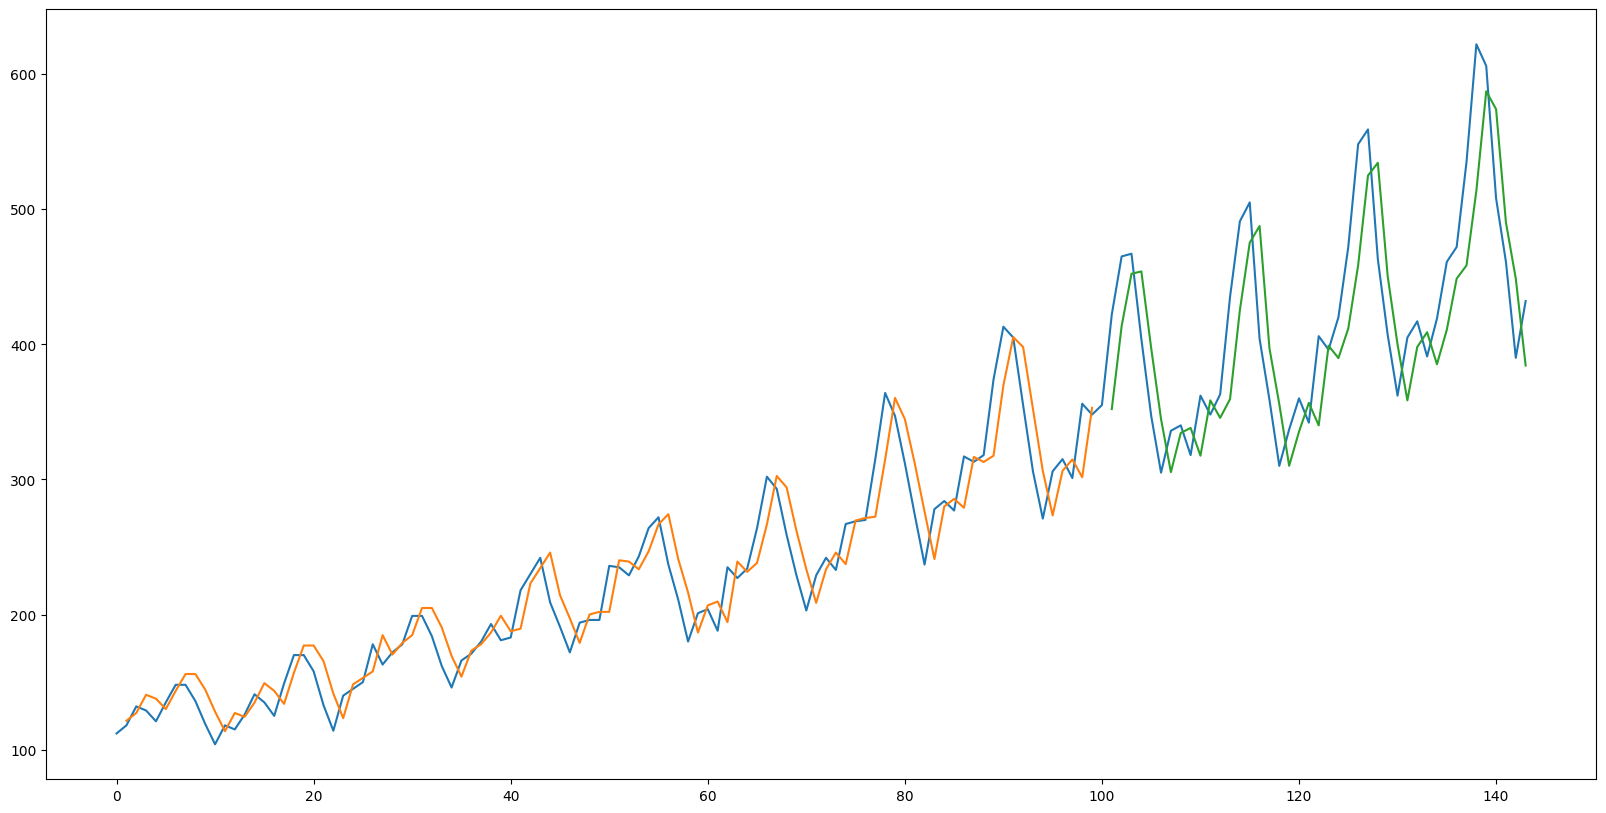

In [76]:
trainPredictPlot = np.empty_like(scaled)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[window_size:len(trainPredict)+window_size, :] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(scaled)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(window_size*2):len(scaled), :] = testPredict

# plot baseline and predictions
plt.figure(figsize=(20,10))
plt.plot(scaler.inverse_transform(scaled))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

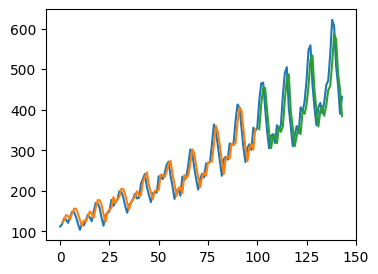

In [77]:
plt.figure(figsize=(4,3))
plt.plot(scaler.inverse_transform(scaled))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()